# Decision 3 — Capital Adequacy under Vendor Uncertainty

**Mechanism.** Physical flood damage raises borrower PD and LGD, increasing expected
credit losses. These losses deplete the bank’s capital base, reducing the CET1 ratio.
The decision is threshold-based: post-stress CET1 below the regulatory minimum = breach.

**Transmission chain:**
```
d_iv → PD_iv = PD_0(1 + α d_iv),  LGD_iv = LGD_0 + λ d_iv
     → Loss_v = Σ_i EAD_i · PD_iv · LGD_iv − EL_0
     → CET1_v = (Capital_0 − Loss_v) / RWA_0
     → 1(CET1_v < CET1̅)
```
RWA is held fixed at baseline to isolate the capital-depletion channel.

In [74]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm as _norm
from scipy.stats import t as _t
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
BLUE, RED, GREY, AMBER = '#4878CF', '#E84D0E', '#888888', '#F0A500'

In [76]:
# =============================================================================
# PARAMETERS — edit here to explore
# =============================================================================

PORTFOLIO_SEED = 42
VENDOR_SEED    = 1       # used for single-vendor diagnostic
N_DRAWS        = 1000    # vendor draws for the RP200-shock CET1 distribution

# Reduced-form transmission
ALPHA              = 3.0       # PD amplification factor
PD_FUNCTIONAL_FORM = 'exponential'  # 'linear'      : PD(d) = PD0 * (1 + ALPHA * d)
                                # 'exponential' : PD(d) = PD0 * exp(ALPHA * d)
LAMBDA = 0.30                  # LGD(d) = LGD0 + LAMBDA * d

# Portfolio distributions
EAD_LOW,  EAD_HIGH  = 0.5,  5.0     # GBPm, Uniform
PD0_MU,   PD0_SIGMA = -5.1, 1.0    # LogNormal; median = 0.4%
LGD0_LOW, LGD0_HIGH = 0.10,  0.35   # Uniform

# Capital position (fixed — not derived from portfolio)
RWA_0       = 1000.0   # GBPm
CAPITAL_0   = 120.0    # GBPm  → baseline CET1 = 12.0%
CET1_HURDLE = 0.105    # 10.5% → 1.5 pp headroom

# t-copula for spatial dependence
# The Gaussian copula has zero tail dependence for any rho < 1, which understates
# the probability of multiple properties flooding severely in the same event.
# The t-copula adds tail dependence via the degrees-of-freedom parameter NU.
# As NU → ∞ it converges to the Gaussian copula.
# Tail dependence coefficient: χ(rho, NU) = 2·t_{NU+1}(−√((NU+1)(1−rho)/(1+rho)))
NU = 4   # degrees of freedom; NU=4 is standard in cat-modelling applications

# Physical hazard simulation
N_VENDOR = 1000     # vendor draws (outer loop)
N_MC     = 10_000  # annual flood scenarios per vendor draw (inner loop)
DEPENDENCE_SCENARIOS = {'Independent (rho=0)':   0.0,
                        'Partial dep. (rho=0.5)': 0.5,
                        'Full dep. (rho=1)':       1.0}

DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

# Print tail dependence coefficients for reference
print(f't-copula  NU={NU}  — tail dependence coefficients χ(rho, NU):')
for rho in [0.0, 0.3, 0.5, 0.7, 1.0]:
    if rho == 0.0:
        chi = 2 * _t.cdf(-np.sqrt((NU + 1) * 1.0 / 1.0), df=NU + 1)
    elif rho == 1.0:
        chi = 1.0
    else:
        chi = 2 * _t.cdf(-np.sqrt((NU + 1) * (1 - rho) / (1 + rho)), df=NU + 1)
    print(f'  rho={rho:.1f}:  χ = {chi:.3f}  '
          f'{"(Gaussian copula: χ = 0)" if rho < 1 else ""}')

t-copula  NU=4  — tail dependence coefficients χ(rho, NU):
  rho=0.0:  χ = 0.076  (Gaussian copula: χ = 0)
  rho=0.3:  χ = 0.162  (Gaussian copula: χ = 0)
  rho=0.5:  χ = 0.253  (Gaussian copula: χ = 0)
  rho=0.7:  χ = 0.391  (Gaussian copula: χ = 0)
  rho=1.0:  χ = 1.000  


In [78]:
# =============================================================================
# DATA, PORTFOLIO AND CAPITAL CALIBRATION
# =============================================================================
df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
n  = len(df)

tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

def tri_sample(rng, a, b, c):
    u     = rng.uniform(size=len(a))
    span  = np.where(b > a, b - a, 1.0)
    fc    = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u,     0) * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u, 0) * span * np.maximum(b - c, 0))
    return np.where(b > a, np.clip(np.where(u <= fc, left, right), 0, 1), a)

def stressed_pd(pd0, d):
    """Apply PD transmission; shape of pd0 and d must broadcast."""
    if PD_FUNCTIONAL_FORM == 'exponential':
        return np.clip(pd0 * np.exp(ALPHA * d), 1e-4, 0.9999)
    else:
        return np.clip(pd0 * (1.0 + ALPHA * d), 1e-4, 0.9999)

# Single vendor draw for diagnostic
d_vendor = tri_sample(np.random.default_rng(VENDOR_SEED), tri_a, tri_b, tri_c)

# Portfolio: draw per-loan EAD, PD0, LGD0
rng      = np.random.default_rng(PORTFOLIO_SEED)
ead      = rng.uniform(EAD_LOW, EAD_HIGH, n)
pd0_arr  = np.clip(
    stats.lognorm.rvs(PD0_SIGMA, scale=np.exp(PD0_MU), size=n,
                      random_state=int(rng.integers(2**31))),
    1e-4, 0.9999)
lgd0_arr = rng.uniform(LGD0_LOW, LGD0_HIGH, n)

# Capital position (fixed — not derived from portfolio)
threshold_loss = CAPITAL_0 - CET1_HURDLE * RWA_0   # GBP 15m

idx = np.argsort(df['mean_dr'].values)

print(f'n = {n} loans  |  Total EAD GBP{ead.sum():.1f}m')
print(f'Median PD0 = {np.median(pd0_arr)*100:.2f}%  |  '
      f'Median LGD0 = {np.median(lgd0_arr)*100:.1f}%')
print(f'PD form: {PD_FUNCTIONAL_FORM}  |  alpha={ALPHA}  lambda={LAMBDA}')
print(f'RWA_0 = {RWA_0:.0f}  |  Capital_0 = {CAPITAL_0:.0f}  |  '
      f'Baseline CET1 = {CAPITAL_0/RWA_0*100:.1f}%')
print(f'CET1 hurdle = {CET1_HURDLE*100:.1f}%  |  '
      f'Max loss before breach = GBP{threshold_loss:.1f}m')

n = 100 loans  |  Total EAD GBP269.0m
Median PD0 = 0.60%  |  Median LGD0 = 22.3%
PD form: exponential  |  alpha=3.0  lambda=0.3
RWA_0 = 1000  |  Capital_0 = 120  |  Baseline CET1 = 12.0%
CET1 hurdle = 10.5%  |  Max loss before breach = GBP15.0m


Vendor 1:  stressed EL GBP1.399m  |  CET1 11.860%  |  breach: False


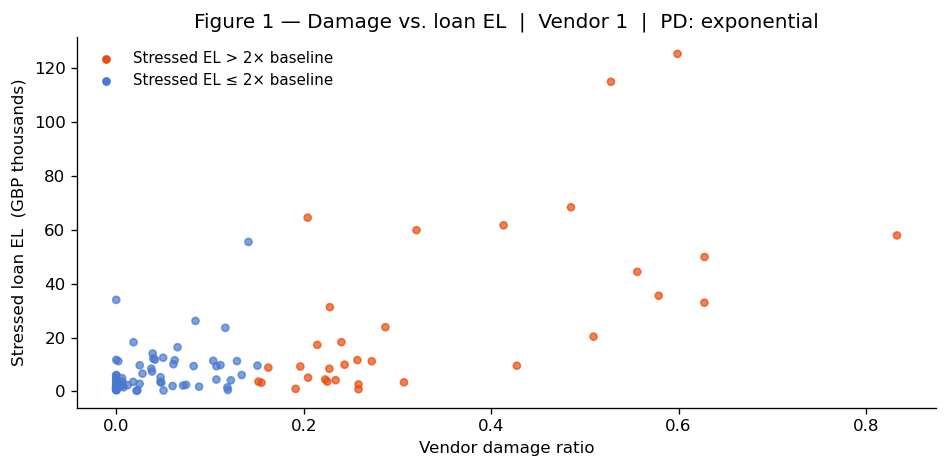

In [80]:
pd_v  = stressed_pd(pd0_arr, d_vendor)
lgd_v = np.minimum(lgd0_arr + LAMBDA * d_vendor, 1.0)
el_v  = ead * pd_v * lgd_v

Loss_v   = el_v.sum()
CET1_v   = (CAPITAL_0 - Loss_v) / RWA_0
breach_v = CET1_v < CET1_HURDLE

print(f'Vendor {VENDOR_SEED}:  stressed EL GBP{Loss_v:.3f}m  |  '
      f'CET1 {CET1_v*100:.3f}%  |  breach: {breach_v}')

fig, ax = plt.subplots(figsize=(8, 4))
above = el_v > ead * pd0_arr * lgd0_arr * 2
ax.scatter(d_vendor[idx], el_v[idx] * 1e3,
           c=np.where(above, RED, BLUE)[idx], s=18, alpha=0.7)
ax.scatter([], [], c=RED,  s=18, label='Stressed EL > 2× baseline')
ax.scatter([], [], c=BLUE, s=18, label='Stressed EL ≤ 2× baseline')
ax.set_xlabel('Vendor damage ratio')
ax.set_ylabel('Stressed loan EL  (GBP thousands)')
ax.set_title(f'Figure 1 — Damage vs. loan EL  |  Vendor {VENDOR_SEED}  '
             f'|  PD: {PD_FUNCTIONAL_FORM}')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

PD form: exponential  |  Breach probability: 0.00%  |  CET1 mean 11.860%  P5–P95: 11.807%–11.891%


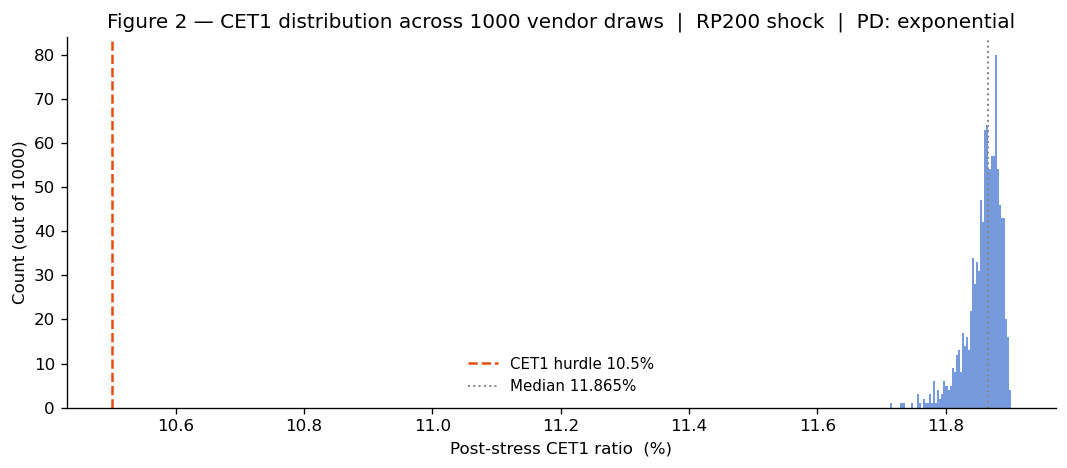

In [82]:
# N_DRAWS triangular samples — each represents one hypothetical vendor
_rng = np.random.default_rng(0)
u_m  = _rng.uniform(size=(N_DRAWS, n))
span = np.where(tri_b > tri_a, tri_b - tri_a, 1.0)
fc   = np.where(tri_b > tri_a, (tri_c - tri_a) / span, 0.0)
lft  = tri_a + np.sqrt(np.maximum(u_m,       0) * span * np.maximum(tri_c - tri_a, 0))
rgt  = tri_b - np.sqrt(np.maximum(1.0 - u_m, 0) * span * np.maximum(tri_b - tri_c, 0))
d_m  = np.where(tri_b > tri_a, np.clip(np.where(u_m <= fc, lft, rgt), 0, 1), tri_a)

pd_m   = stressed_pd(pd0_arr[None, :], d_m)
lgd_m  = np.minimum(lgd0_arr + LAMBDA * d_m, 1.0)
loss_v = (pd_m * lgd_m * ead).sum(axis=1)
cet1_v = (CAPITAL_0 - loss_v) / RWA_0
breach_v = cet1_v < CET1_HURDLE

print(f'PD form: {PD_FUNCTIONAL_FORM}  |  Breach probability: {breach_v.mean():.2%}  |  '
      f'CET1 mean {cet1_v.mean()*100:.3f}%  '
      f'P5–P95: {np.percentile(cet1_v,5)*100:.3f}%–{np.percentile(cet1_v,95)*100:.3f}%')

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(cet1_v.min() * 100, cet1_v.max() * 100, 60)
ax.hist(cet1_v * 100, bins=bins, color=BLUE, alpha=0.75, edgecolor='none')
for patch, b in zip(ax.patches, bins):
    if b < CET1_HURDLE * 100: patch.set_facecolor(RED)
ax.axvline(CET1_HURDLE * 100, color=RED, lw=1.5, ls='--',
           label=f'CET1 hurdle {CET1_HURDLE*100:.1f}%')
ax.axvline(np.median(cet1_v) * 100, color=GREY, lw=1.2, ls=':',
           label=f'Median {np.median(cet1_v)*100:.3f}%')
ax.set_xlabel('Post-stress CET1 ratio  (%)')
ax.set_ylabel(f'Count (out of {N_DRAWS})')
ax.set_title(f'Figure 2 — CET1 distribution across {N_DRAWS} vendor draws  '
             f'|  RP200 shock  |  PD: {PD_FUNCTIONAL_FORM}')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## Single-vendor hazard analysis

Before running the full vendor × MC simulation, we examine what the annual loss distribution looks like for a **single fixed vendor draw** (`VENDOR_SEED`). This isolates the effect of spatial dependence from vendor uncertainty.

**Hazard model:** damage is linearly interpolated in return-period space between two anchors:
- **RP2** (AEP = 0.5): damage = 0 — the flood threshold, below which no structural damage occurs
- **RP200** (AEP = 0.005): damage = `d_vendor` — the vendor's reported damage ratio from the CFRF data

In each of the `N_MC` annual scenarios, a uniform draw `U` is treated as the annual exceedance probability, giving return period `1/U` and damage `d_vendor × clip((1/U − 2) / 198, 0, 1)`. The Gaussian copula controls how correlated those draws are across properties.

**Two outputs:**
- **Loss histogram** — the full distribution of annual portfolio losses across all scenarios
- **EP curve** — the classical cat-modelling exceedance probability plot; by construction the RP200 loss should sit at AEP ≈ 1/200 on this curve

Single vendor draw (seed=1)  |  t-copula NU=4:
  Baseline EL (no flood):           GBP0.5390m  (subtracted)
  RP200 incremental loss:           GBP0.8599m

Scenario                          Mean       P50       P95     P99.5     P99.9  Frac>RP200
Independent (rho=0)             0.0123    0.0068    0.0447    0.1184    0.1257       0.000
Partial dep. (rho=0.5)          0.0130    0.0029    0.0560    0.2741    0.4848       0.000
Full dep. (rho=1)               0.0123    0.0000    0.0345    0.8267    0.8599       0.000


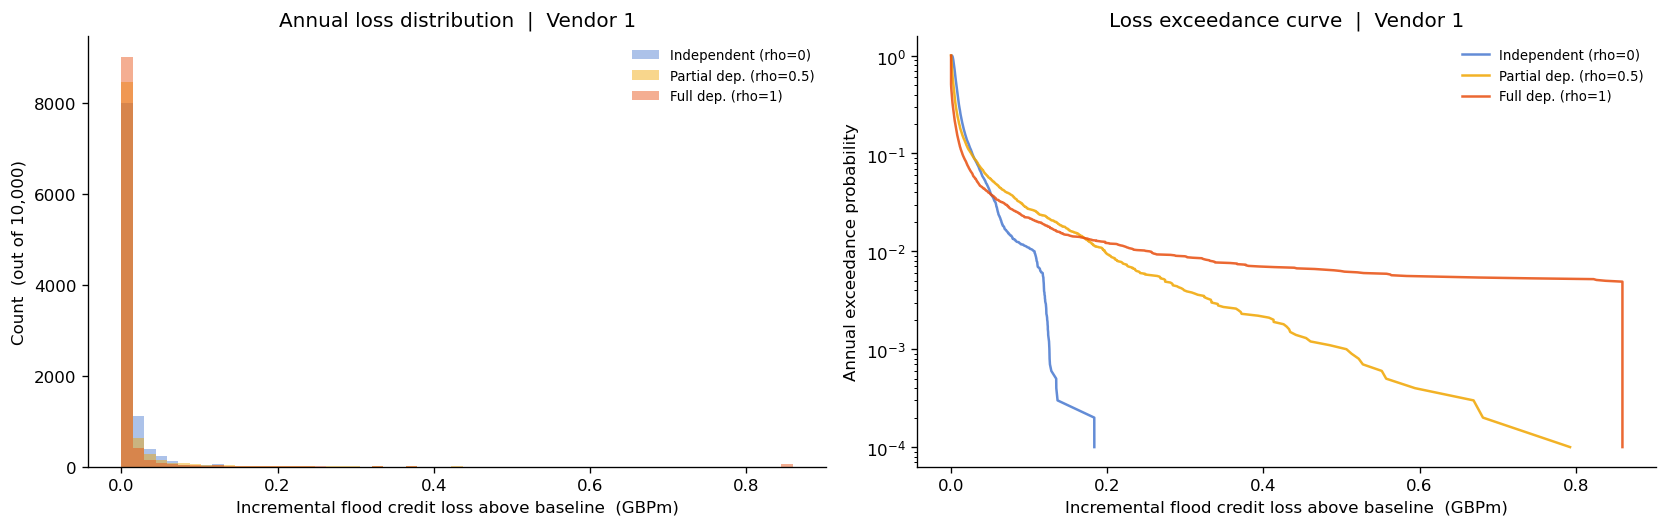

In [85]:
# =============================================================================
# SINGLE-VENDOR HAZARD ANALYSIS — full annual loss distribution
# Uses d_vendor (VENDOR_SEED draw) as the RP200 anchor.
# The hazard model linearly scales damage from 0 at RP2 to d_vendor at RP200.
# Spatial dependence across properties is modelled with a t-copula (NU d.o.f.).
#
# Losses are reported as incremental EL above the no-flood baseline, so the
# distribution floors at 0 for scenarios with AEP > 0.5 (RP < 2, no damage).
# =============================================================================

# Baseline EL: credit losses that exist regardless of flood (d=0)
loss_base_el = (pd0_arr * lgd0_arr * ead).sum()

def annual_loss_distribution(d_k, rho, rng, N):
    """Return N annual flood-driven credit losses (incremental above baseline, floored at 0)."""
    if rho == 1.0:
        U = np.broadcast_to(rng.uniform(size=(N, 1)), (N, n)).copy()
    elif rho == 0.0:
        U = rng.uniform(size=(N, n))  # truly independent: no copula
    else:
        # t-copula: shared chi-squared factor W drives tail co-movement
        W = rng.chisquare(df=NU, size=(N, 1)) / NU
        Z = rng.standard_normal(size=(N, 1))
        e = rng.standard_normal(size=(N, n))
        X = (rho * Z + np.sqrt(1.0 - rho**2) * e) / np.sqrt(W)
        U = _t.cdf(X, df=NU)
    U   = np.maximum(U, 1e-10)
    # Hazard curve: d scales linearly in return-period space from 0 at RP2 to d_k at RP200
    d   = d_k[None, :] * np.clip((1.0 / U - 2.0) / 198.0, 0.0, 1.0)
    pd_ = stressed_pd(pd0_arr, d)
    lg_ = np.minimum(lgd0_arr + LAMBDA * d, 1.0)
    return np.maximum((pd_ * lg_ * ead).sum(axis=1) - loss_base_el, 0.0)

# RP200 incremental loss for this vendor draw (the hazard model ceiling)
loss_rp200 = (stressed_pd(pd0_arr, d_vendor) *
              np.minimum(lgd0_arr + LAMBDA * d_vendor, 1.0) * ead).sum() - loss_base_el

# Generate full annual loss distributions for each dependence scenario
colours_dep = [BLUE, AMBER, RED]
losses_single = {}
_rng_single = np.random.default_rng(42)
for label, rho in DEPENDENCE_SCENARIOS.items():
    losses_single[label] = annual_loss_distribution(d_vendor, rho, _rng_single, N_MC)

# Summary table
print(f'Single vendor draw (seed={VENDOR_SEED})  |  t-copula NU={NU}:')
print(f'  Baseline EL (no flood):           GBP{loss_base_el:.4f}m  (subtracted)')
print(f'  RP200 incremental loss:           GBP{loss_rp200:.4f}m')
print()
print(f'{"Scenario":<28}  {"Mean":>8}  {"P50":>8}  {"P95":>8}  {"P99.5":>8}  {"P99.9":>8}  {"Frac>RP200":>10}')
for label, losses in losses_single.items():
    print(f'{label:<28}  '
          f'{losses.mean():>8.4f}  '
          f'{np.percentile(losses, 50):>8.4f}  '
          f'{np.percentile(losses, 95):>8.4f}  '
          f'{np.percentile(losses, 99.5):>8.4f}  '
          f'{np.percentile(losses, 99.9):>8.4f}  '
          f'{(losses > loss_rp200).mean():>10.3f}')

# --- Figure: overlaid histograms (left) + EP curves (right) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: overlaid loss histograms
ax = axes[0]
all_vals = np.concatenate(list(losses_single.values()))
bins = np.linspace(0, np.percentile(all_vals, 99.9), 60)
for (label, losses), col in zip(losses_single.items(), colours_dep):
    ax.hist(losses, bins=bins, color=col, alpha=0.45, edgecolor='none', label=label)
# ax.axvline(loss_rp200, color='black', lw=1.5, ls='--', label=f'RP200 incremental  {loss_rp200:.3f}m')
ax.set_xlabel('Incremental flood credit loss above baseline  (GBPm)')
ax.set_ylabel(f'Count  (out of {N_MC:,})')
ax.set_title(f'Annual loss distribution  |  Vendor {VENDOR_SEED}')
ax.legend(frameon=False, fontsize=8)

# Right: loss exceedance probability (EP) curve
ax = axes[1]
for (label, losses), col in zip(losses_single.items(), colours_dep):
    sorted_losses = np.sort(losses)[::-1]
    aep = np.arange(1, len(sorted_losses) + 1) / len(sorted_losses)
    ax.plot(sorted_losses, aep, color=col, lw=1.5, alpha=0.85, label=label)
# ax.axvline(loss_rp200, color='black', lw=1.2, ls='--', label=f'RP200  {loss_rp200:.3f}m')
# ax.axhline(1 / 200,   color=GREY,    lw=1.0, ls=':',  label='AEP = 1/200')
ax.set_xlabel('Incremental flood credit loss above baseline  (GBPm)')
ax.set_ylabel('Annual exceedance probability')
ax.set_yscale('log')
ax.set_title(f'Loss exceedance curve  |  Vendor {VENDOR_SEED}')
ax.legend(frameon=False, fontsize=8)

# fig.suptitle(
#     f'Figure — Single-vendor hazard analysis  |  Vendor seed={VENDOR_SEED}  '
#     f'|  {N_MC:,} annual scenarios  |  t-copula NU={NU}  |  PD: {PD_FUNCTIONAL_FORM}',
#     fontsize=10)
plt.tight_layout()
plt.show()

## Diagnostic: why don't losses approach the CET1 threshold?

Before running the full simulation, it is worth asking whether a breach is even structurally possible under this parameterisation, and if so, under what conditions.

Three questions to answer:
1. **Is breach theoretically possible?** — what is the maximum portfolio loss if every property is damaged at `d = 1`?
2. **What damage level is actually needed?** — the breakeven uniform `d` that just crosses the GBP 15m threshold
3. **How far are typical CFRF damage ratios from that breakeven?** — the gap between what the data shows and what would be required

=== Diagnostic: breach feasibility ===
Baseline EL (d=0):               GBP0.539m
Max possible EL (d=1, all):      GBP26.386m
CET1 breach threshold:           GBP15.0m
Max loss / threshold:            175.9%
=> Breach IS theoretically possible but requires near-maximum damage on all properties.

Portfolio EL at uniform damage ratio d (PD form: exponential, alpha=3.0):
      d   EL (GBPm)   % of threshold
   0.00       0.539            3.6%
   0.05       0.671            4.5%
   0.10       0.832            5.5%
   0.15       1.027            6.8%
   0.20       1.264            8.4%
   0.30       1.897           12.6%
   0.50       4.151           27.7%
   0.70       8.830           58.9%
   0.85      15.336          102.2%  *** BREACH ***
   1.00      26.386          175.9%  *** BREACH ***

CFRF data reality check:
  Properties with zero damage across all vendors: 25 / 100
  mean_dr  —  median: 0.080  mean: 0.112  max: 0.610
  max_dr   —  median: 0.250  P90: 1.000  max: 1.000
  Mean dam

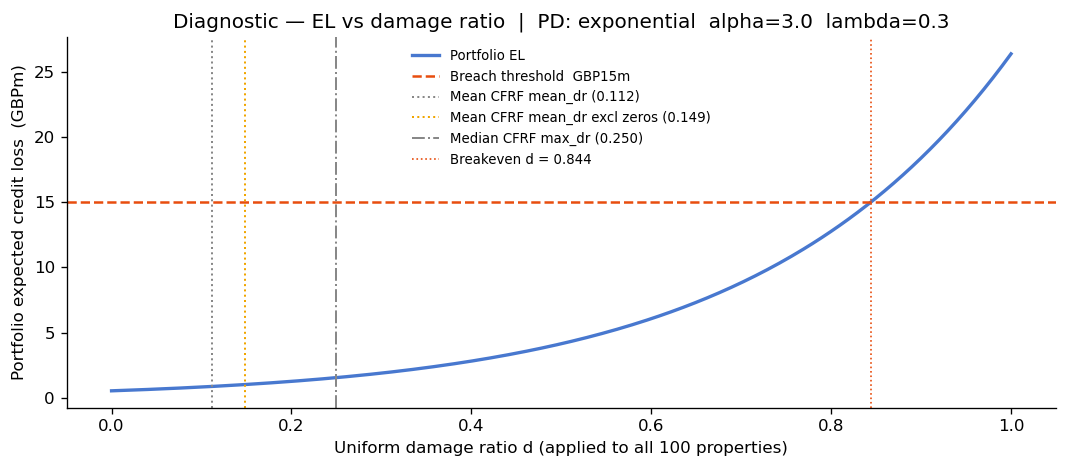

In [88]:
# =============================================================================
# DIAGNOSTIC: why do losses stay far below the CET1 breach threshold?
# Three questions:
#   1. Is breach even theoretically possible under this model?
#   2. Where is the ceiling? (max possible loss)
#   3. What damage level would be needed to breach?
# =============================================================================

# --- 1. Theoretical ceiling: d=1 for all 100 properties simultaneously ---
pd_dmax  = np.clip(pd0_arr * np.exp(ALPHA * 1.0), 1e-4, 0.9999)
lgd_dmax = np.minimum(lgd0_arr + LAMBDA * 1.0, 1.0)
loss_dmax = (pd_dmax * lgd_dmax * ead).sum()

loss_base = (stressed_pd(pd0_arr, np.zeros(n)) * np.minimum(lgd0_arr, 1.0) * ead).sum()

print('=== Diagnostic: breach feasibility ===')
print(f'Baseline EL (d=0):               GBP{loss_base:.3f}m')
print(f'Max possible EL (d=1, all):      GBP{loss_dmax:.3f}m')
print(f'CET1 breach threshold:           GBP{threshold_loss:.1f}m')
print(f'Max loss / threshold:            {loss_dmax/threshold_loss:.1%}')
print(f'=> Breach IS theoretically possible but requires near-maximum damage on all properties.')
print()

# --- 2. Sweep uniform damage ratio: how close do typical CFRF levels get? ---
d_vals = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.70, 0.85, 1.0])
print(f'Portfolio EL at uniform damage ratio d (PD form: {PD_FUNCTIONAL_FORM}, alpha={ALPHA}):')
print(f'  {"d":>5}  {"EL (GBPm)":>10}  {"% of threshold":>15}')
for d_val in d_vals:
    pd_ = np.clip(pd0_arr * np.exp(ALPHA * d_val), 1e-4, 0.9999)
    lg_ = np.minimum(lgd0_arr + LAMBDA * d_val, 1.0)
    l = (pd_ * lg_ * ead).sum()
    marker = '  *** BREACH ***' if l > threshold_loss else ''
    print(f'  {d_val:5.2f}  {l:>10.3f}  {l/threshold_loss:>14.1%}{marker}')
print()

# --- 3. CFRF damage ratio reality check ---
mean_dr_all    = df['mean_dr'].mean()
mean_dr_nonzero = df.loc[df['mean_dr'] > 0, 'mean_dr'].mean()
med_max_dr     = df['maximum_dr'].median()
print('CFRF data reality check:')
print(f'  Properties with zero damage across all vendors: {(df["mean_dr"]==0).sum()} / {n}')
print(f'  mean_dr  —  median: {df["mean_dr"].median():.3f}  mean: {mean_dr_all:.3f}  max: {df["mean_dr"].max():.3f}')
print(f'  max_dr   —  median: {med_max_dr:.3f}  P90: {df["maximum_dr"].quantile(0.9):.3f}  max: {df["maximum_dr"].max():.3f}')
print(f'  Mean damage ratio (non-zero properties only): {mean_dr_nonzero:.3f}')
print()

# At mean CFRF damage levels, what fraction of threshold do we reach?
for label_d, d_val in [('mean_dr (all props)', mean_dr_all),
                        ('mean_dr (non-zero only)', mean_dr_nonzero),
                        ('median max_dr', med_max_dr)]:
    pd_ = np.clip(pd0_arr * np.exp(ALPHA * d_val), 1e-4, 0.9999)
    lg_ = np.minimum(lgd0_arr + LAMBDA * d_val, 1.0)
    l = (pd_ * lg_ * ead).sum()
    print(f'  Uniform d = {label_d} ({d_val:.3f}):  EL = GBP{l:.3f}m  ({l/threshold_loss:.1%} of threshold)')
print()

# --- 4. What d is needed to breach? (binary search) ---
lo, hi = 0.0, 1.0
for _ in range(40):
    mid = (lo + hi) / 2
    pd_ = np.clip(pd0_arr * np.exp(ALPHA * mid), 1e-4, 0.9999)
    lg_ = np.minimum(lgd0_arr + LAMBDA * mid, 1.0)
    if (pd_ * lg_ * ead).sum() < threshold_loss:
        lo = mid
    else:
        hi = mid
breakeven_d = (lo + hi) / 2
print(f'Breakeven: uniform d = {breakeven_d:.3f} needed to breach (CFRF median max_dr = {med_max_dr:.3f})')
print(f'=> Breakeven d is {breakeven_d/med_max_dr:.1f}× the median max vendor damage ratio.')

# --- Figure: loss vs uniform d, with CFRF reference lines ---
fig, ax = plt.subplots(figsize=(9, 4))
d_sweep = np.linspace(0, 1, 300)
losses_sweep = []
for d in d_sweep:
    pd_ = np.clip(pd0_arr * np.exp(ALPHA * d), 1e-4, 0.9999)
    lg_ = np.minimum(lgd0_arr + LAMBDA * d, 1.0)
    losses_sweep.append((pd_ * lg_ * ead).sum())
losses_sweep = np.array(losses_sweep)

ax.plot(d_sweep, losses_sweep, color=BLUE, lw=2, label='Portfolio EL')
ax.axhline(threshold_loss, color=RED,  lw=1.5, ls='--', label=f'Breach threshold  GBP{threshold_loss:.0f}m')
ax.axvline(mean_dr_all,    color=GREY, lw=1.2, ls=':',  label=f'Mean CFRF mean_dr ({mean_dr_all:.3f})')
ax.axvline(mean_dr_nonzero,color=AMBER,lw=1.2, ls=':',  label=f'Mean CFRF mean_dr excl zeros ({mean_dr_nonzero:.3f})')
ax.axvline(med_max_dr,     color=GREY, lw=1.2, ls='-.',  label=f'Median CFRF max_dr ({med_max_dr:.3f})')
ax.axvline(breakeven_d,    color=RED,  lw=1.0, ls=':',   label=f'Breakeven d = {breakeven_d:.3f}')
ax.set_xlabel('Uniform damage ratio d (applied to all 100 properties)')
ax.set_ylabel('Portfolio expected credit loss  (GBPm)')
ax.set_title(f'Diagnostic — EL vs damage ratio  |  PD: {PD_FUNCTIONAL_FORM}  alpha={ALPHA}  lambda={LAMBDA}')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

P99.5 incremental flood credit loss — vendor uncertainty across 1000 draws
  Scenario                          Mean        SD       CV    Median        P5       P95
  Independent (rho=0)             0.2063    0.1621    0.786    0.1471    0.0719    0.5319
  Partial dep. (rho=0.5)          0.3054    0.1467    0.480    0.2582    0.1712    0.5977
  Full dep. (rho=1)               0.7740    0.2671    0.345    0.7145    0.4534    1.2831


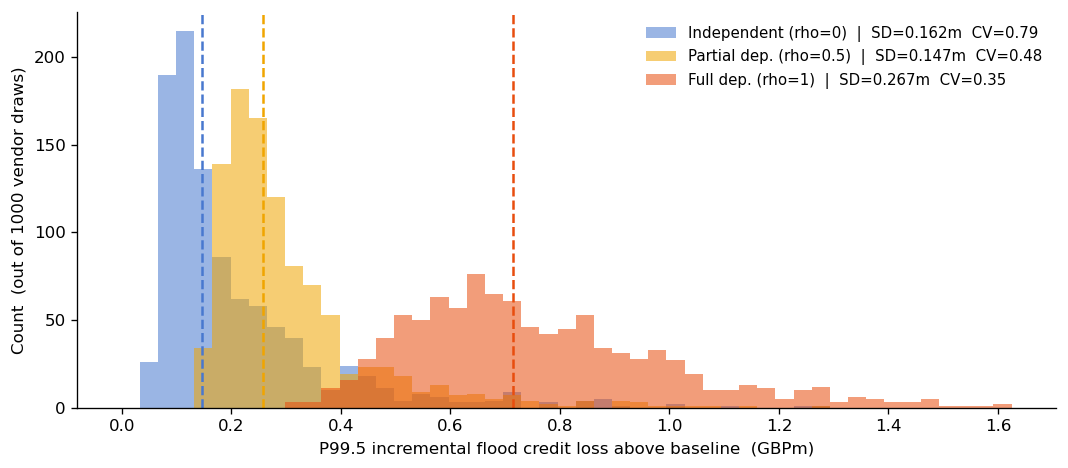

In [90]:
# Physical hazard simulation: for each of N_VENDOR vendor draws, run N_MC annual
# flood scenarios and record the P99.5 portfolio credit loss.
# Outer loop = vendor uncertainty; inner loop = physical hazard + spatial dependence.
# Spatial dependence modelled with a t-copula (NU degrees of freedom).
# Losses are incremental above the no-flood baseline, so the floor is 0.

def sample_p995(d_k, rho, rng):
    """P99.5 incremental flood credit loss for vendor draw d_k under t-copula with correlation rho."""
    N = N_MC
    if rho == 1.0:
        U = np.broadcast_to(rng.uniform(size=(N, 1)), (N, n)).copy()
    elif rho == 0.0:
        U = rng.uniform(size=(N, n))
    else:
        W = rng.chisquare(df=NU, size=(N, 1)) / NU
        Z = rng.standard_normal(size=(N, 1))
        e = rng.standard_normal(size=(N, n))
        X = (rho * Z + np.sqrt(1.0 - rho**2) * e) / np.sqrt(W)
        U = _t.cdf(X, df=NU)
    U    = np.maximum(U, 1e-10)
    d    = d_k[None, :] * np.clip((1.0 / U - 2.0) / 198.0, 0.0, 1.0)
    pd_  = stressed_pd(pd0_arr, d)
    lg_  = np.minimum(lgd0_arr + LAMBDA * d, 1.0)
    loss = np.maximum((pd_ * lg_ * ead).sum(axis=1) - loss_base_el, 0.0)
    return np.percentile(loss, 99.5)

# Pre-compute N_VENDOR triangular vendor draws
_rng_v = np.random.default_rng(0)
_u     = _rng_v.uniform(size=(N_VENDOR, n))
span   = np.where(tri_b > tri_a, tri_b - tri_a, 1.0)
fc     = np.where(tri_b > tri_a, (tri_c - tri_a) / span, 0.0)
lft    = tri_a + np.sqrt(np.maximum(_u,     0) * span * np.maximum(tri_c - tri_a, 0))
rgt    = tri_b - np.sqrt(np.maximum(1 - _u, 0) * span * np.maximum(tri_b - tri_c, 0))
d_vmat = np.where(tri_b > tri_a, np.clip(np.where(_u <= fc, lft, rgt), 0, 1), tri_a)

# Collect P99.5 for each vendor × dependence scenario
colours_dep = [BLUE, AMBER, RED]
p995 = {}
for label, rho in DEPENDENCE_SCENARIOS.items():
    _rng_mc = np.random.default_rng(42)
    p995[label] = np.array([sample_p995(d_vmat[k], rho, _rng_mc)
                             for k in range(N_VENDOR)])

# Summary statistics
print(f'P99.5 incremental flood credit loss — vendor uncertainty across {N_VENDOR} draws')
print(f'  {"Scenario":<28}  {"Mean":>8}  {"SD":>8}  {"CV":>7}  '
      f'{"Median":>8}  {"P5":>8}  {"P95":>8}')
for label, vals in p995.items():
    mean = vals.mean()
    sd   = vals.std()
    cv   = sd / mean if mean > 0 else np.nan
    print(f'  {label:<28}  '
          f'{mean:>8.4f}  '
          f'{sd:>8.4f}  '
          f'{cv:>7.3f}  '
          f'{np.median(vals):>8.4f}  '
          f'{np.percentile(vals,5):>8.4f}  '
          f'{np.percentile(vals,95):>8.4f}')

# Figure 3 — three distributions, no title, SD and CV annotated
all_vals = np.concatenate(list(p995.values()))
bins = np.linspace(0, np.percentile(all_vals, 99.5), 50)

fig, ax = plt.subplots(figsize=(9, 4))
for (label, vals), col in zip(p995.items(), colours_dep):
    mean = vals.mean()
    sd   = vals.std()
    cv   = sd / mean if mean > 0 else np.nan
    ax.hist(vals, bins=bins, color=col, alpha=0.55, edgecolor='none',
            label=f'{label}  |  SD={sd:.3f}m  CV={cv:.2f}')
    ax.axvline(np.median(vals), color=col, lw=1.5, ls='--')
ax.set_xlabel('P99.5 incremental flood credit loss above baseline  (GBPm)')
ax.set_ylabel(f'Count  (out of {N_VENDOR} vendor draws)')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

Post-stress CET1 (%)  |  baseline = 12.0%  |  hurdle = 10.5%
  Scenario                           P5   Median      P95   Breach%
  Independent (rho=0)            11.893   11.931   11.939     0.00%
  Partial dep. (rho=0.5)         11.886   11.920   11.929     0.00%
  Full dep. (rho=1)              11.818   11.875   11.901     0.00%


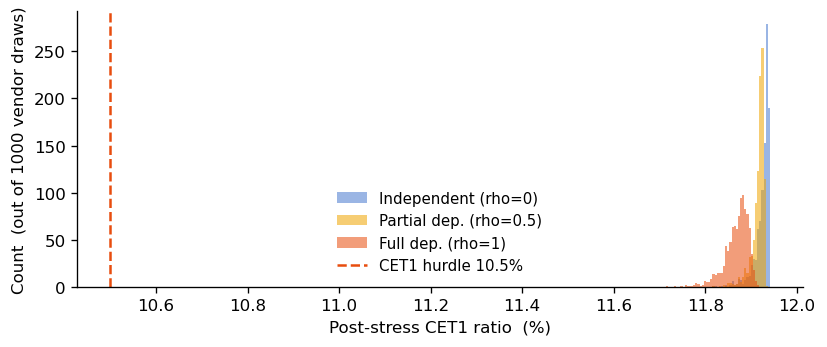

In [91]:
# =============================================================================
# POST-STRESS CET1 RATIO — three dependence assumptions
# CET1_stressed = (Capital_0 − total_P99.5_loss) / RWA_0
# where total = incremental flood loss + baseline EL
# Two versions: one with the regulatory hurdle line, one without.
# =============================================================================

cet1_by_dep = {}
for label, vals in p995.items():
    total_p995 = vals + loss_base_el
    cet1_by_dep[label] = (CAPITAL_0 - total_p995) / RWA_0 * 100   # in %

all_cet1 = np.concatenate(list(cet1_by_dep.values()))
bins_cet1 = np.linspace(all_cet1.min(), all_cet1.max(), 50)

print(f'Post-stress CET1 (%)  |  baseline = {CAPITAL_0/RWA_0*100:.1f}%  '
      f'|  hurdle = {CET1_HURDLE*100:.1f}%')
print(f'  {"Scenario":<28}  {"P5":>7}  {"Median":>7}  {"P95":>7}  {"Breach%":>8}')
for label, vals in cet1_by_dep.items():
    breach = (vals < CET1_HURDLE * 100).mean()
    print(f'  {label:<28}  '
          f'{np.percentile(vals,5):>7.3f}  '
          f'{np.median(vals):>7.3f}  '
          f'{np.percentile(vals,95):>7.3f}  '
          f'{breach:>8.2%}')

# ── Figure: WITH CET1 hurdle ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
for (label, vals), col in zip(cet1_by_dep.items(), colours_dep):
    ax.hist(vals, bins=bins_cet1, color=col, alpha=0.55, edgecolor='none', label=label)
    # ax.axvline(np.median(vals), color=col, lw=1.5, ls='--')
ax.axvline(CET1_HURDLE * 100, color=RED, lw=1.5, ls='--',
           label=f'CET1 hurdle {CET1_HURDLE*100:.1f}%')
# ax.axvspan(bins_cet1[0], CET1_HURDLE * 100, alpha=0.06, color=RED, zorder=0)
ax.set_xlabel('Post-stress CET1 ratio  (%)')
ax.set_ylabel(f'Count  (out of {N_VENDOR} vendor draws)')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# # ── Figure: WITHOUT CET1 hurdle ───────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(9, 4))
# for (label, vals), col in zip(cet1_by_dep.items(), colours_dep):
#     ax.hist(vals, bins=bins_cet1, color=col, alpha=0.55, edgecolor='none', label=label)
#     ax.axvline(np.median(vals), color=col, lw=1.5, ls='--')
# ax.set_xlabel('Post-stress CET1 ratio  (%)')
# ax.set_ylabel(f'Count  (out of {N_VENDOR} vendor draws)')
# ax.legend(frameon=False, fontsize=9)
# plt.tight_layout()
# plt.show()

Pairwise vendor disagreement in P99.5 incremental flood credit loss  (499,500 vendor pairs):
  Scenario                      Median |Δ|     P75 |Δ|     P90 |Δ|     Max |Δ|
  Independent (rho=0)               0.0918      0.1986      0.3623      1.2123
  Partial dep. (rho=0.5)            0.0872      0.1811      0.3348      1.1331
  Full dep. (rho=1)                 0.2147      0.3882      0.6100      2.0100


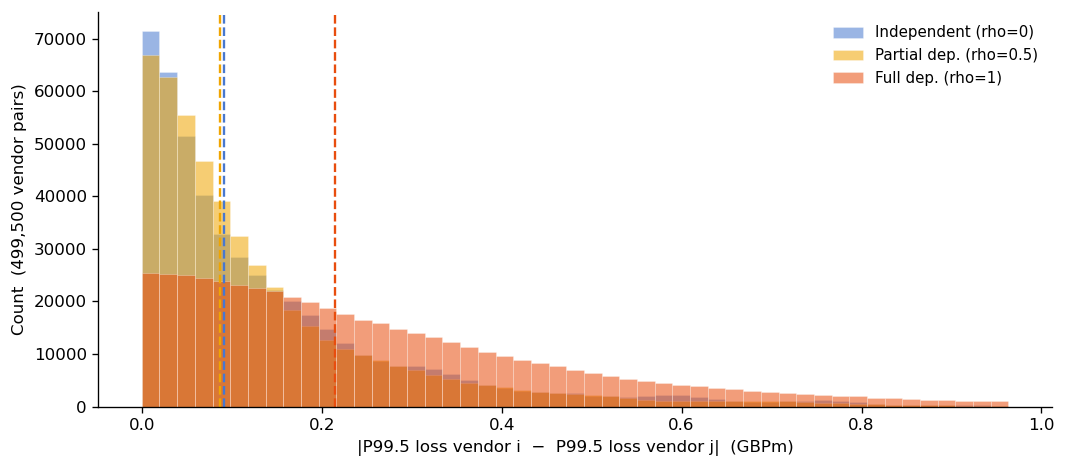

In [92]:
from scipy.stats import gaussian_kde

# =============================================================================
# PAIRWISE VENDOR DISAGREEMENT — incremental flood credit loss
# For each pair of vendor draws (i, j), compute |P99.5_i − P99.5_j|.
# Shows how much the choice of vendor shifts the bank's estimated tail loss.
# Matches the pairwise ECL disagreement figure in Decisions 1 and 2.
# =============================================================================

ii, jj = np.triu_indices(N_VENDOR, k=1)
n_pairs = len(ii)

p995_diffs = {label: np.abs(vals[ii] - vals[jj]) for label, vals in p995.items()}

print(f'Pairwise vendor disagreement in P99.5 incremental flood credit loss  '
      f'({n_pairs:,} vendor pairs):')
print(f'  {"Scenario":<28}  {"Median |Δ|":>10}  {"P75 |Δ|":>10}  '
      f'{"P90 |Δ|":>10}  {"Max |Δ|":>10}')
for label, diffs in p995_diffs.items():
    print(f'  {label:<28}  '
          f'{np.median(diffs):>10.4f}  '
          f'{np.percentile(diffs,75):>10.4f}  '
          f'{np.percentile(diffs,90):>10.4f}  '
          f'{diffs.max():>10.4f}')

all_diffs = np.concatenate(list(p995_diffs.values()))
bins_diff = np.linspace(0, np.percentile(all_diffs, 99), 50)

fig, ax = plt.subplots(figsize=(9, 4))
for (label, diffs), col in zip(p995_diffs.items(), colours_dep):
    ax.hist(diffs, bins=bins_diff, color=col, alpha=0.55,
            edgecolor='white', linewidth=0.3, label=label)
    ax.axvline(np.median(diffs), color=col, lw=1.4, ls='--')
ax.set_xlabel('|P99.5 loss vendor i  −  P99.5 loss vendor j|  (GBPm)')
ax.set_ylabel(f'Count  ({n_pairs:,} vendor pairs)')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Total portfolio credit loss

The figures below express results as **total** portfolio credit loss (incremental flood loss + baseline EL), placing the vendor uncertainty on the same scale as the expected-loss figures in Decisions 1 and 2. The baseline EL is marked as a reference line showing the floor of the distribution — the credit loss the portfolio would generate in a flood-free year.

Baseline portfolio EL (no flood):  GBP0.5390m

Total P99.5 portfolio credit loss  (incremental + baseline):
  Scenario                            P5    Median       P95       Max
  Independent (rho=0)             0.6109    0.6861    1.0709    1.8004
  Partial dep. (rho=0.5)          0.7102    0.7971    1.1367    1.8128
  Full dep. (rho=1)               0.9923    1.2535    1.8220    2.8677


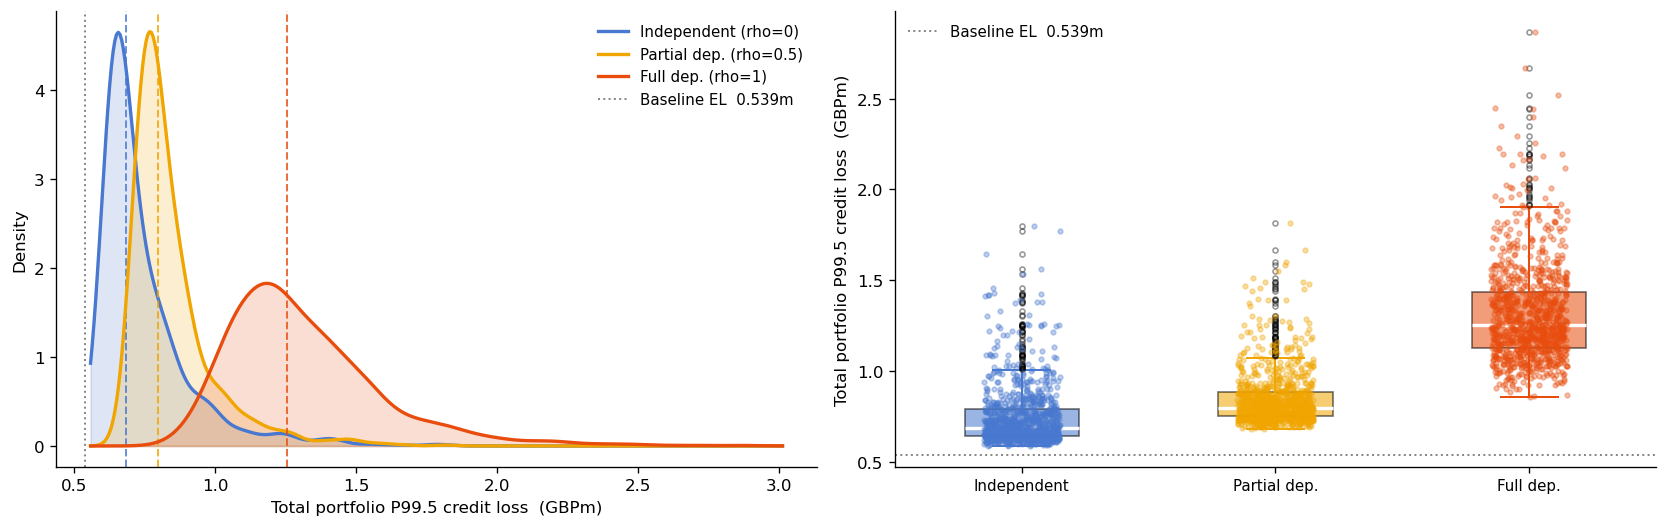

In [94]:
from scipy.stats import gaussian_kde

colours_dep = [BLUE, AMBER, RED]

# Total P99.5 per vendor draw = incremental + baseline
p995_total = {label: vals + loss_base_el for label, vals in p995.items()}

print(f'Baseline portfolio EL (no flood):  GBP{loss_base_el:.4f}m')
print()
print(f'Total P99.5 portfolio credit loss  (incremental + baseline):')
print(f'  {"Scenario":<28}  {"P5":>8}  {"Median":>8}  {"P95":>8}  {"Max":>8}')
for label, vals in p995_total.items():
    print(f'  {label:<28}  '
          f'{np.percentile(vals,5):>8.4f}  '
          f'{np.median(vals):>8.4f}  '
          f'{np.percentile(vals,95):>8.4f}  '
          f'{vals.max():>8.4f}')

# KDE density + strip-box
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
x_min = min(v.min() for v in p995_total.values()) * 0.95
x_max = max(v.max() for v in p995_total.values()) * 1.05
x_grid = np.linspace(x_min, x_max, 400)
for (label, vals), col in zip(p995_total.items(), colours_dep):
    kde = gaussian_kde(vals, bw_method='silverman')
    ax.fill_between(x_grid, kde(x_grid), alpha=0.18, color=col)
    ax.plot(x_grid, kde(x_grid), color=col, lw=2, label=label)
    ax.axvline(np.median(vals), color=col, lw=1.2, ls='--', alpha=0.8)
ax.axvline(loss_base_el, color=GREY, lw=1.2, ls=':',
           label=f'Baseline EL  {loss_base_el:.3f}m')
ax.set_xlabel('Total portfolio P99.5 credit loss  (GBPm)')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
labels_list = list(p995_total.keys())
vals_list   = [p995_total[k] for k in labels_list]
bp = ax.boxplot(vals_list, vert=True, patch_artist=True, widths=0.45,
                medianprops=dict(color='white', lw=2),
                whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, col in zip(bp['boxes'], colours_dep):
    patch.set_facecolor(col); patch.set_alpha(0.55)
for whisker, cap, col in zip(bp['whiskers'][::2], bp['caps'][::2], colours_dep):
    whisker.set_color(col); cap.set_color(col)
for whisker, cap, col in zip(bp['whiskers'][1::2], bp['caps'][1::2], colours_dep):
    whisker.set_color(col); cap.set_color(col)
rng_strip = np.random.default_rng(7)
for i, (vals, col) in enumerate(zip(vals_list, colours_dep), start=1):
    jitter = rng_strip.uniform(-0.15, 0.15, len(vals))
    ax.scatter(i + jitter, vals, color=col, s=8, alpha=0.35, zorder=3)
ax.axhline(loss_base_el, color=GREY, lw=1.2, ls=':',
           label=f'Baseline EL  {loss_base_el:.3f}m')
ax.set_xticks(range(1, len(labels_list) + 1))
ax.set_xticklabels([l.split('(')[0].strip() for l in labels_list], fontsize=9)
ax.set_ylabel('Total portfolio P99.5 credit loss  (GBPm)')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [95]:
print('=== Decision 3 summary ===')
print(f'RWA_0={RWA_0:.0f}  Capital_0={CAPITAL_0:.0f}  '
      f'Baseline CET1={CAPITAL_0/RWA_0*100:.1f}%  Hurdle={CET1_HURDLE*100:.1f}%')
print(f'Max loss before breach = GBP{threshold_loss:.1f}m')
print(f'Baseline EL = GBP{(ead*PD0*LGD0).sum():.3f}m  |  '
      f'PD0={PD0*100:.1f}%  LGD0={LGD0*100:.0f}%  alpha={ALPHA}  lambda={LAMBDA}')
print(f'\nVendor-only (RP200 shock, N={N_DRAWS}):  '
      f'breach {breach_v.mean():.2%}  '
      f'CET1 {np.percentile(cet1_v,5)*100:.3f}–{np.percentile(cet1_v,95)*100:.3f}%')
print(f'\nPhysical hazard (N_VENDOR={N_VENDOR}, N_MC={N_MC:,}):')
for label, vals in p995.items():
    cet1_p995 = (CAPITAL_0 - vals) / RWA_0
    breach_p995 = (vals > threshold_loss).mean()
    print(f'  {label:28s}  median P99.5 loss = GBP{np.median(vals):.3f}m  '
          f'CET1 = {np.median(cet1_p995)*100:.3f}%  '
          f'breach share = {breach_p995:.2%}')

=== Decision 3 summary ===
RWA_0=1000  Capital_0=120  Baseline CET1=12.0%  Hurdle=10.5%
Max loss before breach = GBP15.0m


NameError: name 'PD0' is not defined